# Problema: Ecuación de Laplace en un cuadrado conductor

Consideremos un dominio cuadrado conductor en el plano, con lado de longitud $L$,
discretizado sobre una malla uniforme. El potencial eléctrico $V(x,y)$ en el interior
del dominio satisface la ecuación de Laplace:
$$
\nabla^2 V = 0.
$$

Las condiciones de frontera son:

- La **frontera superior** se mantiene a un potencial constante  
  $$
  V(x, L) = 100 \, \text{V}.
  $$

- Las otras **tres fronteras** (inferior, izquierda y derecha) están puestas a tierra:  
  $$
  V(x, 0) = 0, \qquad V(0, y) = 0, \qquad V(L, y) = 0.
  $$

No hay cargas en el interior del cuadrado.  
El objetivo es determinar el potencial eléctrico $V(x,y)$ en todos los puntos del dominio.



## Serie de Fourier

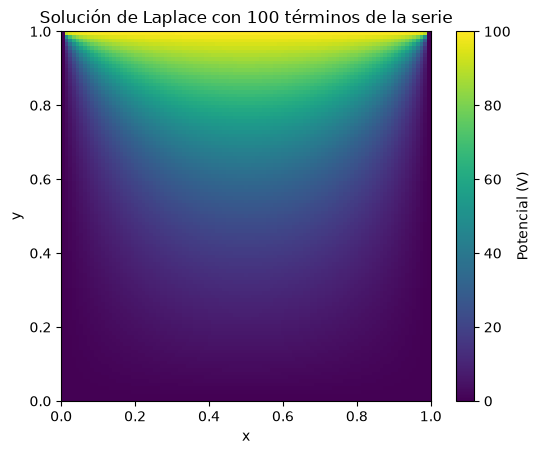

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Parámetros
V0 = 100.0          # Voltaje en la parte superior
n_terms = 100       # Número de términos de la serie
N = 101             # Número de puntos en cada dirección (mallado) -- L
#L=1

x = np.linspace(0, 1, N)
y = np.linspace(0, 1, N)
X, Y = np.meshgrid(x, y)


V = np.zeros_like(X, dtype=float)

# Serie en k: n = 2k+1
for k in range(n_terms):
    n = 2*k + 1
    coef = 4 * V0 / (np.pi * n)
    V += coef * np.sinh(n * np.pi * Y) / np.sinh(n * np.pi) * np.sin(n * np.pi * X)

# Gráfico
plt.figure()

im = plt.imshow(V, vmin=0, vmax=V0, extent=[0,1,0,1], origin="lower") #extent=[xmin, xmax, ymin, ymax] ajusta los límites del gráfico a tu dominio real. #origin="lower" asegura que el eje y empiece en 0 abajo (por defecto imshow pone el origen arriba).
plt.colorbar(im, label="Potencial (V)")

plt.xlabel("x")
plt.ylabel("y")
plt.title(f"Solución de Laplace con {n_terms} términos de la serie")
plt.show()


## Método de diferencias finitas

### Vectorizar vs. no vectorizar

In [2]:
import numpy as np
import time


N = 51
V_top = 100.0

 
def jacobi_scalar(N, tol=1e-6, max_iter=200000, V_top=100.0):
    V = np.zeros((N, N))
    V[:, -1] = V_top 

    for it in range(max_iter):
        V_old = V.copy()

        V_new = V.copy()
        for i in range(1, N-1):
            for j in range(1, N-1):
                V_new[i, j] = 0.25 * (
                    V[i+1, j] + V[i-1, j] +
                    V[i, j+1] + V[i, j-1]
                )

        V = V_new

        # BCs
        V[:, 0] = 0
        V[0, 1] = 0
        V[-1,:] = 0
        V[:,-1] = V_top

        # criterio de convergencia
        diff = np.max(np.abs(V - V_old))
        if diff < tol:
            return V, it+1

    return V, max_iter

def jacobi_vectorized(N, tol=1e-6, max_iter=200000, V_top=100.0):
    V = np.zeros((N, N))
    V[:, -1] = V_top 

    for it in range(max_iter):
        V_old = V.copy()

        V_new = V.copy()
        V_new[1:-1, 1:-1] = 0.25 * (
            V[2:,   1:-1] +
            V[:-2,  1:-1] +
            V[1:-1, 2:]   +
            V[1:-1, :-2]
        )
        V = V_new

        # BCs
        V[:, 0] = 0
        V[0, 1] = 0
        V[-1,:] = 0
        V[:,-1] = V_top

        diff = np.max(np.abs(V - V_old))
        if diff < tol:
            return V, it+1

    return V, max_iter

# timing
t0 = time.time()
jacobi_scalar(N)
t_scalar = time.time()-t0

t0 = time.time()
V,max_iter=jacobi_vectorized(N)
t_vect = time.time()-t0



In [3]:
print(f"Tiempo programa escalar: {t_scalar:.2f}   Tiempo programa vectorizado: {t_vect:.2f}")

print(f"Es decir, el vectorizado es {t_scalar/t_vect:.1f} veces más rápido")

Tiempo programa escalar: 26.19   Tiempo programa vectorizado: 0.33
Es decir, el vectorizado es 78.8 veces más rápido


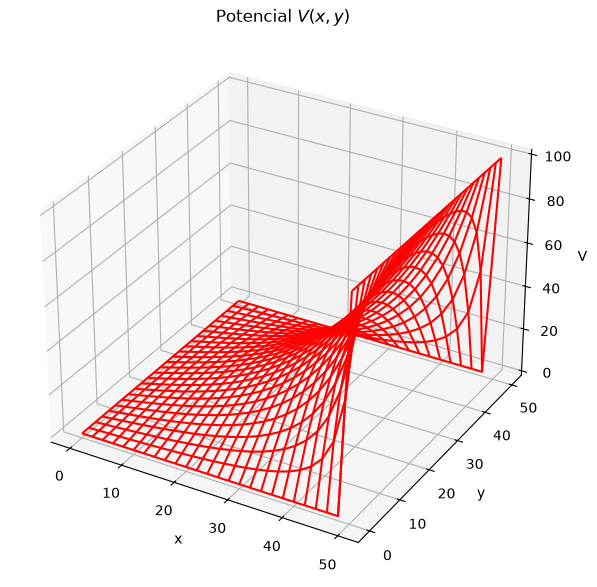

In [4]:

from mpl_toolkits.mplot3d import Axes3D

x = np.arange(0, N, 2)
y = np.arange(0, N, 2)
X, Y = np.meshgrid(x, y)

def func_z(V):
    return V[Y, X]   # cuidado: V[y,x]

Z = func_z(V)

fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')

ax.plot_wireframe(X, Y, Z, color='r')

ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('V')
ax.set_title('Potencial $V(x,y)$')

plt.tight_layout()
plt.show()

### Visualización campo eléctrico
Para visualizar el campo eléctrico a partir del potencial $U(x,y)$,
basta con recordar que

$$
\vec{E} = -\nabla U =
\left( -\frac{\partial U}{\partial x},\;
       -\frac{\partial U}{\partial y} \right).
$$

En una malla discreta con separación uniforme $\Delta$,
las derivadas parciales pueden aproximarse mediante
diferencias centradas. Por ejemplo, para la componente $E_x$:

$$
E_x(x,y)
\simeq
-\frac{U(x+\Delta,y) - U(x-\Delta,y)}{2\Delta}.
$$

Si denotamos por $U_{i,j}$ el valor del potencial en el punto de
índices $(i,j)$, esta expresión se escribe de forma discreta como

$$
E_{x,\,i,j}
\simeq
-\frac{ U_{\,i+1,j} - U_{\,i-1,j} }{ 2\Delta }.
$$

Una vez calculadas las componentes del campo eléctrico en toda la malla,
el campo puede visualizarse mediante flechas de diferentes longitudes y
direcciones (quiver plot), o bien mediante líneas de flujo.


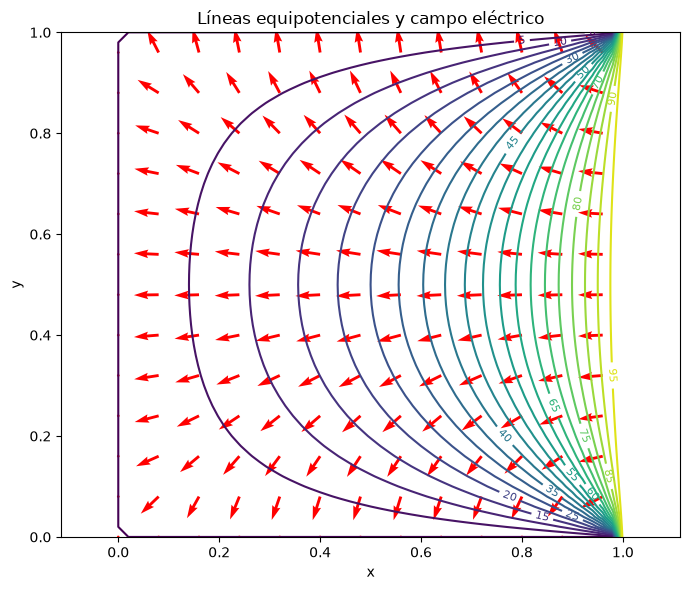

In [5]:
import numpy as np
import matplotlib.pyplot as plt

Ny, Nx = V.shape
x = np.linspace(0, 1, Nx)
y = np.linspace(0, 1, Ny)
X, Y = np.meshgrid(x, y)


# Hacemos diferencias centrales para estimar la derivada
dUdx = np.zeros_like(V)
dUdy = np.zeros_like(V)

dUdx[:, 1:-1] = (V[:, 2:] - V[:, :-2]) / (x[2] - x[0])
dUdy[1:-1, :] = (V[2:, :] - V[:-2, :]) / (y[2] - y[0])

Ex = -dUdx
Ey = -dUdy

# Normalizamos para que las flechas no sean enormes
E_mag = np.sqrt(Ex**2 + Ey**2)
Exn = Ex / (E_mag + 1e-12)
Eyn = Ey / (E_mag + 1e-12)


plt.figure(figsize=(7,6))

# Contornos de potencial (equipotenciales)
cs = plt.contour(X, Y, V, levels=20, cmap='viridis')
plt.clabel(cs, inline=1, fontsize=8)

# Campo eléctrico con flechas
step = 4     
plt.quiver(X[::step, ::step], Y[::step, ::step],
           Exn[::step, ::step], Eyn[::step, ::step],
           color='red', scale=25)

plt.title("Líneas equipotenciales y campo eléctrico")
plt.xlabel("x")
plt.ylabel("y")
plt.axis('equal')
plt.tight_layout()
plt.show()


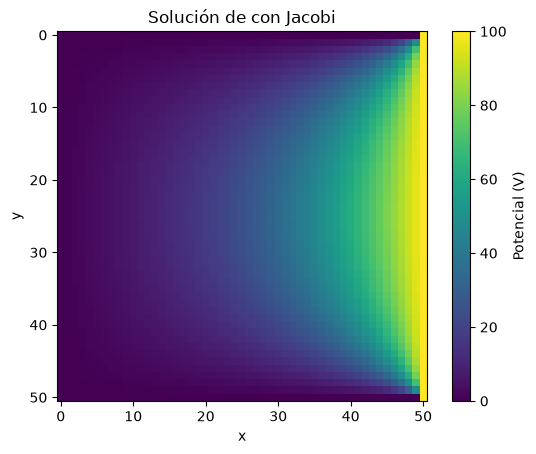

In [6]:
t_scalar, t_vect

im = plt.imshow(V, vmin=0, vmax=V_top)
plt.colorbar(im, label="Potencial (V)")
plt.xlabel("x")
plt.ylabel("y")
plt.title(f"Solución de con Jacobi")
plt.show()

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# Parámetros del problema
V_top = 100.0
N = 101
max_iter = 20000
tol = 1e-6

I, J = np.meshgrid(np.arange(N), np.arange(N), indexing="ij")
white   = (I + J) % 2 == 0
black = ~white

def solve_jacobi():
    V = np.zeros((N, N))
    
    V[:,-1] = V_top
    errors = []

    for it in range(max_iter):
        V_old = V.copy()

        # Jacobi
        V_new = V.copy()
        V_new[1:-1,1:-1] = 0.25 * (
            V[2:,1:-1] + V[:-2,1:-1] + V[1:-1,2:] + V[1:-1,:-2]
        )
        V = V_new

        # BCs
        
        V[:, 0] = 0
        V[0, 1] = 0
        V[-1,:] = 0
        V[:,-1] = V_top

        diff = np.max(np.abs(V - V_old))
        errors.append(diff)

        if diff < tol:
            break

    return errors


def solve_gs_wb():
    V = np.zeros((N,N))
    V[:,-1] = V_top 
    errors = []

    for it in range(max_iter):
        V_old = V.copy()

        # blanco
        GS = V.copy()
        GS[1:-1,1:-1] = 0.25*(V[2:,1:-1] + V[:-2,1:-1] + V[1:-1,2:] + V[1:-1,:-2])
        V[white] = GS[white]

        # NEGRO
        GS = V.copy()
        GS[1:-1,1:-1] = 0.25*(V[2:,1:-1] + V[:-2,1:-1] + V[1:-1,2:] + V[1:-1,:-2])
        V[black] = GS[black]

        # BCs
        V[:, 0] = 0
        V[0, 1] = 0
        V[-1,:] = 0
        V[:,-1] = V_top

        diff = np.max(np.abs(V - V_old))
        errors.append(diff)

        if diff < tol:
            break

    return errors

def solve_sor_wb():
    V = np.zeros((N,N))
    V[:,-1] = V_top
    errors = []

    for it in range(max_iter):
        V_old = V.copy()

        # blanco
        GS = V.copy()
        GS[1:-1,1:-1] = 0.25*(V[2:,1:-1] + V[:-2,1:-1] + V[1:-1,2:] + V[1:-1,:-2])
        V[white] = (1-omega)*V[white] + omega*GS[white]

        # NEGRO
        GS = V.copy()
        GS[1:-1,1:-1] = 0.25*(V[2:,1:-1] + V[:-2,1:-1] + V[1:-1,2:] + V[1:-1,:-2])
        V[black] = (1-omega)*V[black] + omega*GS[black]

        # BCs
        V[:, 0] = 0
        V[0, 1] = 0
        V[-1,:] = 0
        V[:,-1] = V_top

        diff = np.max(np.abs(V - V_old))
        errors.append(diff)

        if diff < tol:
            break

    return errors



Jacobi iter: 20000
GS blanco-negro iter: 10736
SOR iter: 284


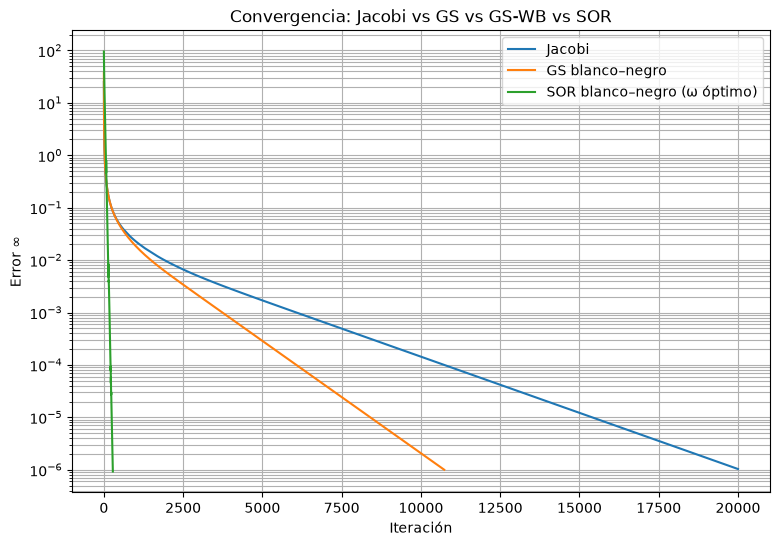

In [8]:

# Parámetro óptimo para SOR
omega = 2.0 / (1.0 + np.sin(np.pi / N))

err_jacobi  = solve_jacobi()
err_gs_rb   = solve_gs_wb()
err_sor     = solve_sor_wb()

print("Jacobi iter:", len(err_jacobi))
print("GS blanco-negro iter:", len(err_gs_rb))
print("SOR iter:", len(err_sor))


plt.figure(figsize=(9,6))
plt.semilogy(err_jacobi,  label="Jacobi")
plt.semilogy(err_gs_rb,   label="GS blanco–negro")
plt.semilogy(err_sor,     label="SOR blanco–negro (ω óptimo)")
plt.xlabel("Iteración")
plt.ylabel("Error ∞")
plt.title("Convergencia: Jacobi vs GS vs GS-WB vs SOR")
plt.grid(True, which="both")
plt.legend()
plt.show()


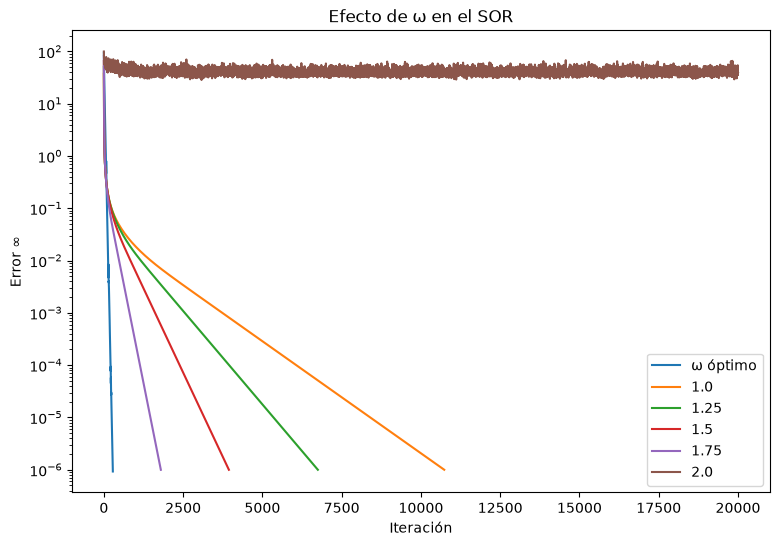

In [9]:

plt.figure(figsize=(9,6))


omega = 2.0 / (1.0 + np.sin(np.pi / N))
err_sor     = solve_sor_wb()
plt.semilogy(err_sor,     label="ω óptimo")


list_omega=np.linspace(1,2,5)
for omega in list_omega:
    err_sor     = solve_sor_wb()
    plt.semilogy(err_sor,     label=str(omega))


plt.xlabel("Iteración")
plt.ylabel("Error ∞")
plt.title("Efecto de ω en el SOR")
plt.legend()
plt.show()


## Ejercicio: Condensador realista en una caja conectada a tierra

En los cursos estándar de ecuaciones diferenciales parciales se estudia el capacitor ideal formado por dos placas paralelas infinitas, para el cual el campo eléctrico es uniforme entre las placas. Sin embargo, en un capacitor realista (de tamaño finito) el campo se deforma cerca de los bordes (efectos de borde) y se extiende más allá de las placas (campos de fuga).

Vamos a modelizar un condensador más realista utilizando el esquema numérico que ya hemos desarrollado para resolver la ecuación de Laplace en una caja cuadrada.

Considera una caja conductora conectada a tierra (todas sus paredes a potencial cero) que contiene en su interior dos placas conductoras delgadas, de longitud y anchura finitas, dispuestas horizontalmente y centradas dentro de la caja (como en la figura). 

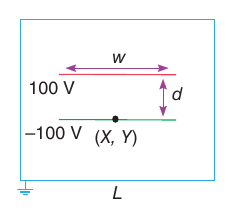

Supondremos que:

* la **placa superior** es una lámina conductora muy fina mantenida a $+100,\text{V}$,
* la **placa inferior** es una lámina conductora muy fina mantenida a $-100,\text{V}$,
* las paredes de la caja están a potencial $0,\text{V}$ (conectadas a tierra).

Al ser conductoras, las placas son superficies equipotenciales, y una batería puede mantenerlas de forma ideal en estos voltajes constantes.

1. Adapta el programa que resuelve la ecuación de Laplace
   $$
   \nabla^2 U(x,y) = 0
   $$
   en la caja, para incorporar ahora estas **condiciones de contorno internas**: fija el potencial a $+100,\text{V}$ en los nodos que representan la placa superior, a $-100,\text{V}$ en los nodos de la placa inferior y a $0,\text{V}$ en las paredes de la caja.

2. Calcula numéricamente el potencial $U(x,y)$ en todo el dominio.

3. Representa:

   * las **líneas equipotenciales** de $U(x,y)$,
   * el **campo eléctrico** $\vec{E}(x,y) = -\nabla U(x,y)$ mediante flechas o líneas de campo.

4. Compara cualitativamente el campo obtenido con el caso ideal de placas infinitas:

   * ¿en qué región se aproxima el campo al campo uniforme ideal?,
   * ¿cómo se manifiestan los efectos de borde y los campos de fuga?



Iteraciones: 485


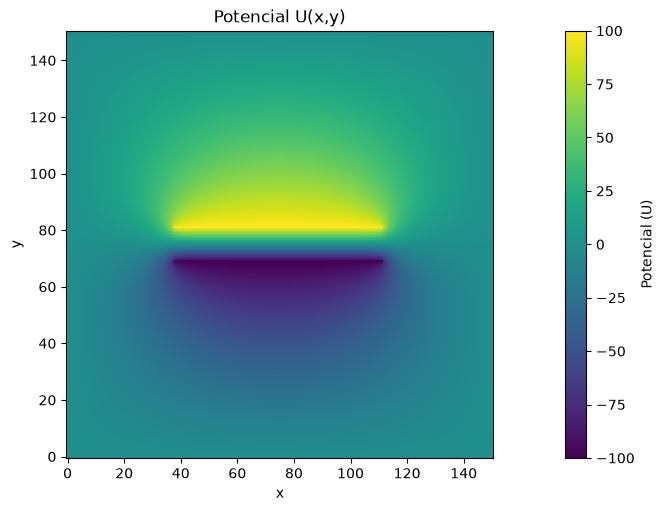

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


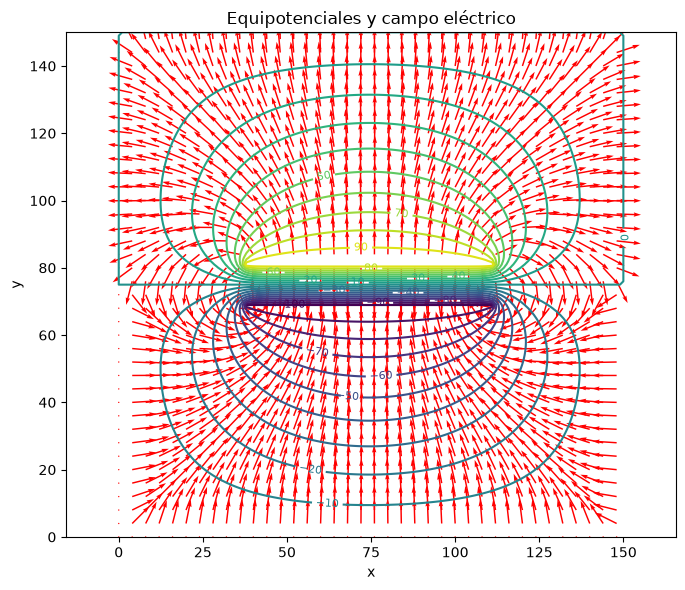

In [10]:
import numpy as np
import matplotlib.pyplot as plt

# Parámetros del dominio
N = 151            # tamaño de la rejilla
V_top_plate = +100.0
V_bottom_plate = -100.0
tol = 1e-6
max_iter = 200000

# placas: rectángulos finitos centrados
margin = N // 6 
plate_width = N // 2
plate_gap = N // 12   # distancia entre placas

# Coordenadas del centro horizontal
cx = N // 2
x1 = cx - plate_width // 2
x2 = cx + plate_width // 2

# Posiciones verticales de las placas (superior e inferior)
y_center = N // 2
y_top = y_center + plate_gap // 2
y_bottom = y_center - plate_gap // 2

# Máscaras de nodos fijos (paredes y placas)
fixed = np.zeros((N, N), dtype=bool) #máscara booleana
U_fixed = np.zeros((N, N), dtype=float)

# Paredes a 0 V
U_fixed[0, :] = 0.0
U_fixed[-1, :] = 0.0
U_fixed[:, 0] = 0.0
U_fixed[:, -1] = 0.0
fixed[0, :] = True
fixed[-1, :] = True
fixed[:, 0] = True
fixed[:, -1] = True

# Placa superior +100 V (una lámina de 1 nodo de grosor)
U_fixed[y_top, x1:x2] = V_top_plate
fixed[y_top, x1:x2] = True

# Placa inferior -100 V
U_fixed[y_bottom, x1:x2] = V_bottom_plate
fixed[y_bottom, x1:x2] = True

def solve_jacobi(N, U_fixed, fixed, tol=1e-6, max_iter=200000):
    U = np.zeros((N, N), dtype=float)
    U[fixed] = U_fixed[fixed]

    for it in range(max_iter):
        U_old = U.copy()

        # actualización Jacobi en puntos libres
        U_new = U.copy()
        U_new[1:-1, 1:-1] = 0.25 * (
            U[2:,   1:-1] +
            U[:-2,  1:-1] +
            U[1:-1, 2:]   +
            U[1:-1, :-2]
        )

        # restaura los nodos fijos
        U = U_new
        U[fixed] = U_fixed[fixed]

        diff = np.max(np.abs(U - U_old))
        if diff < tol:
            return U, it+1
    return U, max_iter

def solve_sor(N, U_fixed, fixed, omega, tol=1e-6, max_iter=200000):
    U = np.zeros((N, N), dtype=float)
    U[fixed] = U_fixed[fixed]

    for it in range(max_iter):
        U_old = U.copy()

        for i in range(1, N-1):
            for j in range(1, N-1):
                if fixed[i, j]:
                    continue
                gs = 0.25 * (U[i+1, j] + U[i-1, j] + U[i, j+1] + U[i, j-1])
                U[i, j] = (1 - omega) * U[i, j] + omega * gs

        U[fixed] = U_fixed[fixed]

        diff = np.max(np.abs(U - U_old))
        if diff < tol:
            return U, it+1
    return U, max_iter

omega = 2.0 / (1.0 + np.sin(np.pi / N))
U, iters = solve_sor(N, U_fixed, fixed, omega, tol=tol, max_iter=max_iter)
print(f"Iteraciones: {iters}")



# Malla para dibujar
y = np.arange(N)
x = np.arange(N)
X, Y = np.meshgrid(x, y)

# Visualizaciones
fig, axs = plt.subplots(1, 1, figsize=(16, 5), constrained_layout=True)

# 1) mapa de potencial (imshow)
im = plt.imshow(U, origin='lower')#, cmap='coolwarm'
plt.colorbar(im, label="Potencial (U)")
plt.title('Potencial U(x,y)')
plt.xlabel('x')
plt.ylabel('y')

plt.show()

# Supongamos que ya tienes U (potencial) de tamaño N x N
Ny, Nx = U.shape
x = np.arange(Nx)
y = np.arange(Ny)
X, Y = np.meshgrid(x, y)

# Derivadas centrales
dUdx = np.zeros_like(U)
dUdy = np.zeros_like(U)
dUdx[:, 1:-1] = (U[:, 2:] - U[:, :-2]) / 2.0
dUdy[1:-1, :] = (U[2:, :] - U[:-2, :]) / 2.0

Ex = -dUdx
Ey = -dUdy

# Normalización
E_mag = np.sqrt(Ex**2 + Ey**2)
Exn = Ex / (E_mag + 1e-12)
Eyn = Ey / (E_mag + 1e-12)

plt.figure(figsize=(7,6))

# Equipotenciales
cs = plt.contour(X, Y, U, levels=20, cmap='viridis')
plt.clabel(cs, inline=1, fontsize=8)

# Campo eléctrico
step = 4
plt.quiver(X[::step, ::step], Y[::step, ::step],
           Exn[::step, ::step], Eyn[::step, ::step],
           color='red', scale=25)

plt.title("Equipotenciales y campo eléctrico")
plt.xlabel("x")
plt.ylabel("y")
plt.axis('equal')
plt.xlim(0, Nx-1)
plt.ylim(0, Ny-1)
plt.tight_layout()
plt.show()

#El campo es uniforme mientras se situe en la zona central del las placas, en los bordes se producen las condiciones de frontera y los campos de fuga
#dando lugar a un campo menos uniforme.
